In [1]:
import pandas as pd
import numpy as np
import os

from datetime import datetime
from sklearn.cluster import KMeans

from check_lang import lang_checker_langdetect, id_to_en
from functions import *
from Preprocessing import *

# pd.options.mode.chained_assignment = None  # default='warn'

d:\GitHub\Jurnal-Clustering\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('data/data_sinta_cleaned_s1.csv')
df

,eissn,DOI,title,abstract,published_date,year,data_cleaned,lang,label
0,25024760,10.11591/ijeecs.v1.i1.pp119-125,localization schemes in underwater sensor netw...,<jats:p>&lt;p&gt;Underwater Wireless Sensor Ne...,2015-11-30,2015.0,localization schemes in underwater sensor netw...,en,80
1,25024760,10.11591/ijeecs.v1.i1.pp53-59,a review on voltage balancing solutions in mul...,<jats:p>&lt;p&gt;Multilevel inverters are used...,2015-11-30,2015.0,a review on voltage balancing solutions in mul...,en,80
2,25024760,10.11591/ijeecs.v1.i1.pp109-118,collision detection and trajectory planning fo...,<jats:p>This paper proposes an algorithm for C...,2016-01-01,2016.0,collision detection and trajectory planning fo...,en,80
3,25024760,10.11591/ijeecs.v1.i1.pp17-30,a new method for optimal coordination of overc...,<jats:p>&lt;p&gt;The most of the new protectiv...,2016-01-01,2016.0,a new method for optimal coordination of overc...,en,80
4,25024760,10.11591/ijeecs.v1.i1.pp176-181,fairness evaluation and comparison of current ...,<jats:p>Transmission Control Protocol (TCP) is...,2016-01-01,2016.0,fairness evaluation and comparison of current ...,en,80
...,...,...,...,...,...,...,...,...,...
57024,25409581,10.22146/jtbb.88238,hesperitin synergistically promotes the senesc...,"<jats:p>Pentagamavunone-1 (PGV-1), a curcumin ...",2024-03-04,2024.0,hesperitin synergistically promotes the senesc...,en,94
57025,25409581,10.22146/jtbb.86455,first report on wild occurrences of phoenix mu...,<jats:p>The genus Pleurotus is known as a comm...,2024-03-08,2024.0,first report on wild occurrences of phoenix mu...,en,94
57026,25409581,10.22146/jtbb.85308,nannoplankton biostratigraphy from banggai-sul...,<jats:p>The nannoplankton research was conduct...,2024-03-11,2024.0,nannoplankton biostratigraphy from banggaisula...,en,94
57027,25409581,10.22146/jtbb.76841,spatial modelling habitat suitability of javan...,<jats:p>Javan Langur (T. auratus) is well-know...,2024-03-15,2024.0,spatial modelling habitat suitability of javan...,en,94


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57029 entries, 0 to 57028
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   eissn           57029 non-null  object 
 1   DOI             57029 non-null  object 
 2   title           57029 non-null  object 
 3   abstract        57029 non-null  object 
 4   published_date  57029 non-null  object 
 5   year            57029 non-null  float64
 6   data_cleaned    57022 non-null  object 
 7   lang            57029 non-null  object 
 8   label           57029 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 3.9+ MB


In [4]:
# # df = pd.read_csv('data/data_sinta_cleaned_s1.csv')

# df.rename(columns= {'desc':'abstract', 'journal' : 'eissn'}, inplace=True)
# df.dropna(inplace=True)
# df.drop_duplicates(inplace=True)

# df.title = df.title.apply(lambda x : x.lower())

# df

In [ ]:
# df['data_cleaned'] = df.abstract.apply(preprocess_text)
# df['data_cleaned'] = df.loc[:, ['title', 'data_cleaned']].apply(lambda x : '{} {}'.format(x[0], x[1]), axis = 1)  
# df['lang'] = df.data_cleaned.apply(lang_checker_langdetect)
df = df[df.lang.isin(['en', 'id'])]
# df.loc[:, 'label'] = 0

df

,eissn,DOI,title,abstract,published_date,year,data_cleaned,lang,label
0,25024760,10.11591/ijeecs.v1.i1.pp119-125,localization schemes in underwater sensor netw...,<jats:p>&lt;p&gt;Underwater Wireless Sensor Ne...,2015-11-30,2015.0,localization schemes in underwater sensor netw...,en,80
1,25024760,10.11591/ijeecs.v1.i1.pp53-59,a review on voltage balancing solutions in mul...,<jats:p>&lt;p&gt;Multilevel inverters are used...,2015-11-30,2015.0,a review on voltage balancing solutions in mul...,en,80
2,25024760,10.11591/ijeecs.v1.i1.pp109-118,collision detection and trajectory planning fo...,<jats:p>This paper proposes an algorithm for C...,2016-01-01,2016.0,collision detection and trajectory planning fo...,en,80
3,25024760,10.11591/ijeecs.v1.i1.pp17-30,a new method for optimal coordination of overc...,<jats:p>&lt;p&gt;The most of the new protectiv...,2016-01-01,2016.0,a new method for optimal coordination of overc...,en,80
4,25024760,10.11591/ijeecs.v1.i1.pp176-181,fairness evaluation and comparison of current ...,<jats:p>Transmission Control Protocol (TCP) is...,2016-01-01,2016.0,fairness evaluation and comparison of current ...,en,80
...,...,...,...,...,...,...,...,...,...
57024,25409581,10.22146/jtbb.88238,hesperitin synergistically promotes the senesc...,"<jats:p>Pentagamavunone-1 (PGV-1), a curcumin ...",2024-03-04,2024.0,hesperitin synergistically promotes the senesc...,en,94
57025,25409581,10.22146/jtbb.86455,first report on wild occurrences of phoenix mu...,<jats:p>The genus Pleurotus is known as a comm...,2024-03-08,2024.0,first report on wild occurrences of phoenix mu...,en,94
57026,25409581,10.22146/jtbb.85308,nannoplankton biostratigraphy from banggai-sul...,<jats:p>The nannoplankton research was conduct...,2024-03-11,2024.0,nannoplankton biostratigraphy from banggaisula...,en,94
57027,25409581,10.22146/jtbb.76841,spatial modelling habitat suitability of javan...,<jats:p>Javan Langur (T. auratus) is well-know...,2024-03-15,2024.0,spatial modelling habitat suitability of javan...,en,94


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_checkpoint = 'google/multiberts-seed_3'
# model_bert = BertClassifierEmbed(123, model_checkpoint)
# checkpoint_bert = torch.load(bert_path)
# model_bert.load_state_dict(checkpoint_bert)

C:\Users\rarmn\AppData\Local\Temp\ipykernel_6304\206730897.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_bert = torch.load(bert_path)


<All keys matched successfully>

In [ ]:
journal_type = 'pipeline_3/sinta_1_ver8_finetuned_silhouette'
journal_type2 = 'pipeline_3/sinta_1'

file_path = os.path.join('src', journal_type)

if not os.path.exists(file_path):
    os.mkdir(file_path)

In [9]:
def inject_data(eissn, journal_type, data, kmeans, pca, threshold):

    embeddings = embed(data, model_checkpoint, device = device)

    X = embeddings.reshape(embeddings.shape[0], -1)
    X = pca.transform(X)

    inject_labels = kmeans.predict(X)

    scoop_labels = np.ones(len(X))
    jarak_ke_centroid = centroid_dist(kmeans, X, label=inject_labels) #Menghitung jarak antara setiap titik data dengan centroid
    scoop_labels[jarak_ke_centroid > threshold] = -1

    filepath = f'./src/{journal_type}/{eissn}'
    np.save(f"{filepath}/{eissn}_pca_data_inject.npy", X)

    df_res = data
    df_res.loc[:, 'kmeans_labels'] = inject_labels
    df_res.loc[:, 'scoop_labels'] = scoop_labels
    df_res.to_csv(f'{filepath}/{eissn}_data_jurnal_inject.csv') 

    return df_res, X

In [ ]:
for eissn in list(df.eissn.unique()):
    if os.path.exists(os.path.join(file_path, eissn)):
        continue

    year_now = datetime.now().year

    data = df[df.eissn == eissn]

    train_df = data[data.year < year_now - 2]
    inject_df = data[data.year >= year_now - 2]

    if len(train_df) <= 0:
        continue
    
    embeddings = embed(train_df, model_checkpoint, device = device)

    X = embeddings.reshape(embeddings.shape[0], -1)

    pca = PCA(n_components=2, random_state=0)
    X = pca.fit_transform(X)

    if len(X) < 10:
        max_cluster = len(X)
    else:
        max_cluster = 10

    opt_k = determine_best_k(X, max_cluster)
    kmeans = KMeans(n_clusters=opt_k, random_state=0, max_iter=1000)
    kmeans.fit(X)

    kmeans_labels = kmeans.labels_
    jarak_ke_centroid = centroid_dist(kmeans, X) #Menghitung jarak antara setiap titik data dengan centroid
    threshold = outscoop_threshold(jarak_ke_centroid) # Menentukan batas jarak yang dianggap sebagai "outscoop"
    scoop_labels = np.ones(len(X))
    scoop_labels[jarak_ke_centroid > threshold] = -1

    df_res = train_df
    df_res['kmeans_labels'] = kmeans_labels

    save_data(eissn, journal_type, kmeans, threshold, X, df_res, scoop_labels, pca)

    if len(inject_df) > 0:
        inject_data(eissn, journal_type, inject_df, kmeans, pca, threshold)
    else:
        continue

    print(f"Data sebaran PCA {eissn} telah disimpan.")


d:\GitHub\Jurnal-Clustering\venv\lib\site-packages\transformers\models\bert\modeling_bert.py:439: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


KeyboardInterrupt: 

In [13]:
df.eissn.unique()

array(['25024760', '23387238', '2442-8620', '25278045', '27224708',
       '24610399', '26141566', '24423084', '27155072', '24769304',
       '26148013', '27765938', '2406825x', '20888708', '22528938',
       '25488465', '25023357', '24070610', '24610275', '23029277',
       '24610771', '25499904', '22524940', '24606952', '23029285',
       '24606278', '25277456', '25494333', '20854722', '24609196',
       '2338557X', '24432555', '25025791', '24606618', '26156636',
       '24078646', '23548509', '25992147', '24607010', '20888694',
       '24429899', '23556544', '25493167', '25481592', '23556145',
       '23385499', '19782993', '25989685', '24609285', '23549203',
       '24778036', '25483161', '27222594', '25483382', '25027883',
       '24774073', '27156079', '25495747', '26153386', '24067598',
       '24077542', '25992570', '24068799', '24068195', '25029266',
       '23561424', '23385510', '25279238', '23389486', '26219468',
       '20864094', '25804391', '24601578', '20892063', '25021

In [15]:
def load_data(journal_id, journal_type):
    file_path = f"./src/{journal_type}/{journal_id}"
    kmeans_model = joblib.load(f"{file_path}/{journal_id}_kmeans.pkl")
    pca_model = joblib.load(f"{file_path}/{journal_id}_kmeans.pkl")
    pca_data = np.load(f"{file_path}/{journal_id}_pca_data.npy")
    threshold = np.load(f"{file_path}/{journal_id}_threshold.npy")
    df_res = pd.read_csv(f"{file_path}/{journal_id}_data_jurnal.csv")
    df_res_inject = pd.read_csv(f"{file_path}/{journal_id}_data_jurnal_inject.csv")
    pca_data_inject = np.load(f"{file_path}/{journal_id}_pca_data_inject.npy")
    return kmeans_model, threshold, pca_data, df_res, pca_model, df_res_inject, pca_data_inject

In [1]:
journal_id = '25025791'

kmeans, threshold, X, df_res, pca, df_res_inject, pca_data_inject = load_data(journal_id, journal_type2)
# journal = list(df_res.journal.apply(lambda x : 1 if x == '25277456' else 0))
scoop_labels = list(df_res.scoop_labels)
lang = list(df_res.lang)
# journal = list(df_res.journal)

# plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='True', label = df_res.kmeans_labels, lang = lang, new_data_pca=pca_data_inject)

print(journal_type2)
plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='focus', label = df_res.kmeans_labels, lang = lang)
plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='focus', label = df_res.kmeans_labels, lang = lang, new_data_pca=pca_data_inject, scoop_labels_inject=df_res_inject.scoop_labels)

df_res[df_res.scoop_labels == -1][['DOI', 'data_cleaned']].head(2).to_clipboard()


NameError: name 'load_data' is not defined

pipeline_3/sinta_1_ver2


d:\GitHub\Jurnal-Clustering\functions.py:68: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  plot = sns.scatterplot(x='Dimension 1', y='Dimension 2', hue='plot_color', data=df_pca, palette=cluster_palette)


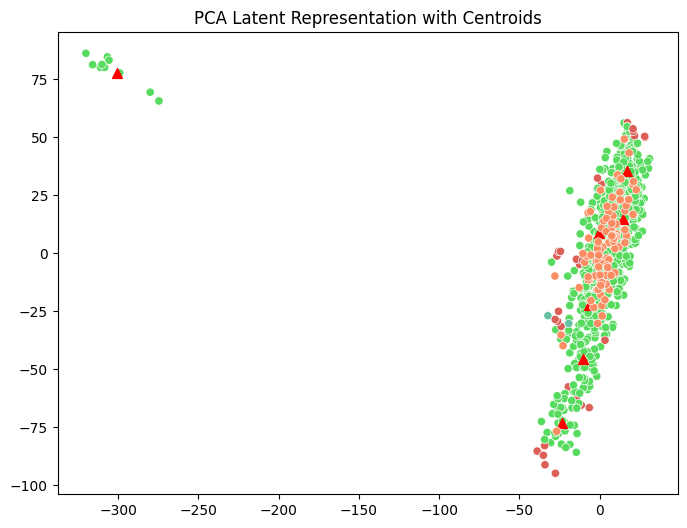

In [10]:
# journal_id = '25024760'

kmeans, threshold, X, df_res, pca, df_res_inject, pca_data_inject = load_data(journal_id, journal_type)
# journal = list(df_res.journal.apply(lambda x : 1 if x == '25277456' else 0))
scoop_labels = list(df_res.scoop_labels)
lang = list(df_res.lang)
# journal = list(df_res.journal)

# plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='True', label = df_res.kmeans_labels, lang = lang, new_data_pca=pca_data_inject)

print(journal_type)
plot_vector_distribution(X, kmeans, scoop_labels, check_outscoop='focus', label = df_res.kmeans_labels, lang = lang, new_data_pca=pca_data_inject, scoop_labels_inject=df_res_inject.scoop_labels)

df_res[df_res.scoop_labels == -1][['DOI', 'data_cleaned']].head(2).to_clipboard()


In [36]:
df_res[df_res.scoop_labels == 1]

,Unnamed: 0,eissn,DOI,title,abstract,published_date,year,data_cleaned,lang,label,kmeans_labels,scoop_labels
0,0,25024760,10.11591/ijeecs.v1.i1.pp119-125,localization schemes in underwater sensor netw...,<jats:p>&lt;p&gt;Underwater Wireless Sensor Ne...,2015-11-30,2015.0,localization schemes in underwater sensor netw...,en,0,0,1.0
1,1,25024760,10.11591/ijeecs.v1.i1.pp53-59,a review on voltage balancing solutions in mul...,<jats:p>&lt;p&gt;Multilevel inverters are used...,2015-11-30,2015.0,a review on voltage balancing solutions in mul...,en,0,5,1.0
2,2,25024760,10.11591/ijeecs.v1.i1.pp109-118,collision detection and trajectory planning fo...,<jats:p>This paper proposes an algorithm for C...,2016-01-01,2016.0,collision detection and trajectory planning fo...,en,0,6,1.0
3,3,25024760,10.11591/ijeecs.v1.i1.pp17-30,a new method for optimal coordination of overc...,<jats:p>&lt;p&gt;The most of the new protectiv...,2016-01-01,2016.0,a new method for optimal coordination of overc...,en,0,5,1.0
4,4,25024760,10.11591/ijeecs.v1.i1.pp176-181,fairness evaluation and comparison of current ...,<jats:p>Transmission Control Protocol (TCP) is...,2016-01-01,2016.0,fairness evaluation and comparison of current ...,en,0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5742,5848,25024760,10.11591/ijeecs.v35.i2.pp704-710,lifetime (bx) improvement of pv inverter using...,<jats:p>Technological advancements have made i...,2024-08-01,2024.0,lifetime (bx) improvement of pv inverter using...,en,0,5,1.0
5743,5849,25024760,10.11591/ijeecs.v35.i2.pp1325-1332,evaluating machine learning models for precipi...,<jats:p>Accurate precipitation forecasting is ...,2024-08-01,2024.0,evaluating machine learning models for precipi...,en,0,2,1.0
5744,5850,25024760,10.11591/ijeecs.v35.i2.pp779-786,an autonomous robotic arm for efficient rock c...,<jats:p>The autonomous rock collector using ro...,2024-08-01,2024.0,an autonomous robotic arm for efficient rock c...,en,0,1,1.0
5745,5851,25024760,10.11591/ijeecs.v35.i2.pp729-742,investigations of bldc motor speed characteris...,<jats:p>This project investigates brushless di...,2024-08-01,2024.0,investigations of bldc motor speed characteris...,en,0,1,1.0


In [11]:
from keybert import KeyBERT

journal_ids = os.listdir(os.path.join('src', journal_type))

dataset_silhouette_score = []

for journal_id in journal_ids:

    kmeans, threshold, X, df_res, pca, df_res_inject, pca_data_inject = load_data(journal_id, journal_type)

    keyphrase = {}

    kw_model = KeyBERT()

    avg_silh_score = silhouette_score(X, df_res.kmeans_labels)
    dataset_silhouette_score.append(avg_silh_score)

    for k in range(len(kmeans.cluster_centers_)):
        doc = ' '.join(list(df_res[df_res.kmeans_labels == k].data_cleaned))
        keywords = kw_model.extract_keywords(doc)

        keyphrase[k] = keywords

    output = {
        'cluster' : [],
        'key' : []
    }

    for i, j in keyphrase.items():
        output['cluster'].append(i)
        output['key'].append(j)

    filepath = os.path.join('src', journal_type, journal_id)
    output = pd.DataFrame(output)
    output.to_csv(f'{filepath}/keyphrase.csv')

    print(journal_id, 'success', '\nsilhouette score : ', avg_silh_score)

np.array(dataset_silhouette_score).mean()

d:\GitHub\Jurnal-Clustering\venv\lib\site-packages\transformers\models\bert\modeling_bert.py:439: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


1907770x success 
silhouette score :  0.36577039420997826
19782993 success 
silhouette score :  0.3822708330169836
1979570X success 
silhouette score :  0.37249948929730947
20854722 success 
silhouette score :  0.3030048958318459
20864094 success 
silhouette score :  0.35305063094163497


FileNotFoundError: [Errno 2] No such file or directory: './src/pipeline_3/sinta_1_ver2/20875886/20875886_data_jurnal_inject.csv'

In [12]:
jurnal_ids = '25024760'

kmeans, threshold, X, df_res = load_data(jurnal_id, journal_type)
keyphrase = pd.read_csv(os.path.join('src', journal_type, jurnal_id, 'keyphrase_sinta1_3_1.csv'))
keyphrase[['cluster', 'key']]

,cluster,key
0,0,"[('mosquito', 0.4243), ('insecticide', 0.4009)..."
1,1,"[('drying', 0.34), ('dryer', 0.3397), ('clothe..."
2,2,"[('mosquito', 0.3295), ('biomass', 0.3279), ('..."
3,3,"[('electrolytes', 0.4285), ('electrolyte', 0.4..."
4,4,"[('hz', 0.3492), ('filter', 0.3253), ('frequen..."
5,5,"[('chiller', 0.3861), ('teaching', 0.3608), ('..."
